In [438]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import wfdb
import ast
from tqdm import tqdm
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [ ]:
DATA_PATH = "C:\\Users\\Me\\Desktop\\ECG\\"
SAMPLING_RATE = 100
BATCH_SIZE = 64
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [440]:
Y = pd.read_csv(DATA_PATH + "ptbxl_database.csv", index_col="ecg_id")
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

In [441]:
agg_df = pd.read_csv(DATA_PATH + "scp_statements.csv", index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

Y["diagnostic_superclass"] = Y.scp_codes.apply(aggregate_diagnostic)

In [442]:
CACHE_FILE = os.path.join(DATA_PATH, "X.npy")

def load_raw_data(df, sampling_rate, path, cache_file):
    # ✅ If cache exists → load instantly
    if os.path.exists(cache_file):
        print("Loading preprocessed data from cache...")
        X = np.load(cache_file, mmap_mode='r')
        print("Done. Shape:", X.shape)
        return X

    if sampling_rate == 100:
        files = df.filename_lr
    else:
        files = df.filename_hr

    data = []
    for f in tqdm(files, desc="Loading ECG signals"):
        signal, _ = wfdb.rdsamp(os.path.join(path, f))
        data.append(signal)

    X = np.array(data)

    np.save(cache_file, X)
    print(f"Saved cache to {cache_file}")

    return X

X = load_raw_data(Y, SAMPLING_RATE, DATA_PATH, CACHE_FILE)


Loading preprocessed data from cache...
Done. Shape: (21799, 1000, 12)


In [443]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(Y["diagnostic_superclass"])

class_names = mlb.classes_
class_names

array(['CD', 'HYP', 'MI', 'NORM', 'STTC'], dtype=object)

In [444]:
test_fold = 10

train_idx = np.where(Y.strat_fold != test_fold)[0]
test_idx  = np.where(Y.strat_fold == test_fold)[0]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

X_train.shape, X_test.shape

((19601, 1000, 12), (2198, 1000, 12))

In [445]:
class_counts = y_train.sum(axis=0)
total_samples = y_train.shape[0]

pos_weight = (total_samples - class_counts) / class_counts

pos_weight = torch.tensor(pos_weight, dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

pos_weight: tensor([3.4527, 7.2116, 2.9848, 1.2922, 3.1580], device='cuda:0')


In [446]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [447]:
train_loader = DataLoader(
    ECGDataset(X_train, y_train),
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    ECGDataset(X_test, y_test),
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [448]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # if channels change, adjust shortcut
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        out += identity
        out = self.relu(out)
        
        return out

In [449]:
class ECGNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        
        self.block1 = ResidualBlock(12, 64)
        self.block2 = ResidualBlock(64, 128)
        self.block3 = ResidualBlock(128, 256)
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        x = self.pool(x).squeeze(-1)
        
        x = self.classifier(x)
        return x

In [450]:
model = ECGNet(len(class_names)).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

In [451]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.permute(0, 2, 1).to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss = 0

    all_logits = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.permute(0, 2, 1).to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)

            all_logits.append(logits.cpu())
            all_targets.append(y.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_logits),
        torch.cat(all_targets)
    )

In [452]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, _, _ = evaluate(model, test_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train {train_loss:.4f} | Val {val_loss:.4f}")

Epoch 1: Train 0.7206 | Val 0.7639
Epoch 2: Train 0.6133 | Val 0.6073
Epoch 3: Train 0.5837 | Val 0.6094
Epoch 4: Train 0.5562 | Val 0.5989
Epoch 5: Train 0.5402 | Val 0.5951
Epoch 6: Train 0.5337 | Val 0.5770
Epoch 7: Train 0.5206 | Val 0.5528
Epoch 8: Train 0.5158 | Val 0.5491
Epoch 9: Train 0.5073 | Val 0.5470
Epoch 10: Train 0.5024 | Val 0.5471


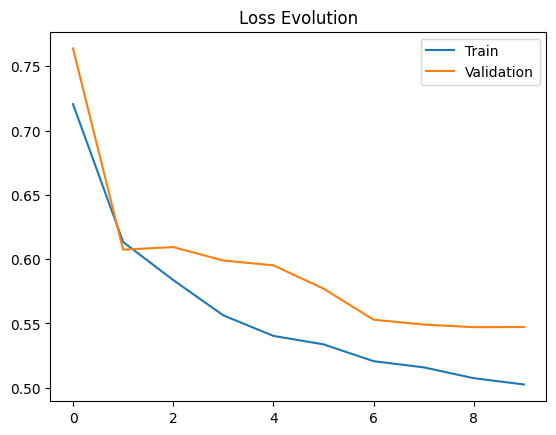

In [453]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss Evolution")
plt.show()

In [454]:
model = ECGNet(n_classes=len(class_names)).to(device)
model.load_state_dict(torch.load("ecg_model.pth"))
model.eval()

C:\Users\Me\AppData\Local\Temp\ipykernel_19228\2866287146.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("ecg_model.pth"))


ECGNet(
  (block1): ResidualBlock(
    (conv1): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(12, 64, kernel_size=(1,), stride=(1,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (block2): ResidualBlock(
    (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv1d(64, 128

In [455]:
_, logits, targets = evaluate(model, test_loader)
probs = torch.sigmoid(logits).numpy()
best_thresholds = {}

for i, cls in enumerate(class_names):
    best_f1 = 0
    best_t = 0.5
    
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (probs[:, i] >= t).astype(int)
        f1 = f1_score(y_true[:, i], preds)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    best_thresholds[cls] = best_t

print("Best thresholds:", best_thresholds)
y_true = targets.numpy()
threshold = 0.3
y_pred = np.zeros_like(probs)

for i, cls in enumerate(class_names):
    t = best_thresholds[cls]
    y_pred[:, i] = (probs[:, i] >= t).astype(int)

torch.save({
    "model_state": model.state_dict(),
    "thresholds": best_thresholds,
    "classes": class_names.tolist()
}, "ecg_full_model.pth")

Best thresholds: {'CD': np.float64(0.7000000000000002), 'HYP': np.float64(0.6500000000000001), 'MI': np.float64(0.45000000000000007), 'NORM': np.float64(0.5500000000000002), 'STTC': np.float64(0.6500000000000001)}


In [456]:
roc_aucs = {}

for i, cls in enumerate(class_names):
    roc_aucs[cls] = roc_auc_score(y_true[:, i], probs[:, i])

roc_aucs["macro"] = roc_auc_score(y_true, probs, average="macro")

roc_aucs

{'CD': 0.8971845267427314,
 'HYP': 0.8986716137783106,
 'MI': 0.9274922771403353,
 'NORM': 0.9384363136453644,
 'STTC': 0.9256979090483533,
 'macro': 0.917496528071019}

In [457]:
ap_scores = {}

for i, cls in enumerate(class_names):
    ap_scores[cls] = average_precision_score(y_true[:, i], probs[:, i])

ap_scores["macro"] = average_precision_score(y_true, probs, average="macro")

ap_scores

{'CD': 0.7991779545930235,
 'HYP': 0.6273219943713791,
 'MI': 0.8341432699783947,
 'NORM': 0.9158381438086864,
 'STTC': 0.802250907505763,
 'macro': 0.7957464540514494}

In [458]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

          CD       0.79      0.67      0.73       496
         HYP       0.59      0.59      0.59       262
          MI       0.67      0.84      0.74       550
        NORM       0.81      0.89      0.85       963
        STTC       0.71      0.79      0.75       521

   micro avg       0.74      0.79      0.76      2792
   macro avg       0.71      0.76      0.73      2792
weighted avg       0.74      0.79      0.76      2792
 samples avg       0.75      0.80      0.75      2792



In [459]:
def prepare_input(signal, device):
    x = torch.tensor(signal, dtype=torch.float32)
    x = x.permute(1, 0)          # (12, 1000)
    x = x.unsqueeze(0).to(device)  # (1, 12, 1000)
    return x

In [460]:
print(type(X_test))
print(type(X_test[0]))
print(X_test[0].shape)

def preprocess_signal(signal):
    # Convert to numpy if needed
    if isinstance(signal, torch.Tensor):
        signal = signal.cpu().numpy()

    if signal.shape == (1000, 12):
        signal = signal.T  # → (12,1000)

    elif signal.shape == (12, 1000):
        pass  # already correct

    else:
        raise ValueError(f"Unexpected shape: {signal.shape}")

    return signal


def predict_signal(model, signal, device):
    model.eval()

    x = prepare_input(signal, device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    return probs

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(1000, 12)


In [461]:

sample = X_test[0]

probs = predict_signal(model, sample, device)

for cls, p in zip(class_names, probs):
    print(f"{cls}: {p:.3f}")

CD: 0.100
HYP: 0.012
MI: 0.048
NORM: 0.969
STTC: 0.007


In [462]:
y_pred = np.zeros_like(probs)

for i, cls in enumerate(class_names):
    t = best_thresholds[cls]
    y_pred[i] = int(probs[i] >= t)

for cls, pred in zip(class_names, y_pred):
    print(f"{cls}: {pred}")

CD: 0.0
HYP: 0.0
MI: 0.0
NORM: 1.0
STTC: 0.0


In [463]:
all_preds = []

for i in range(len(X_test)):
    probs = predict_signal(model, X_test[i], device)

    preds = np.array([
        int(probs[j] >= best_thresholds[class_names[j]])
        for j in range(len(class_names))
    ])

    all_preds.append(preds)

all_preds = np.array(all_preds)

In [464]:
from sklearn.metrics import classification_report

print(classification_report(y_test, all_preds, target_names=class_names))

              precision    recall  f1-score   support

          CD       0.79      0.67      0.73       496
         HYP       0.59      0.59      0.59       262
          MI       0.67      0.84      0.74       550
        NORM       0.81      0.89      0.85       963
        STTC       0.71      0.79      0.75       521

   micro avg       0.74      0.79      0.76      2792
   macro avg       0.71      0.76      0.73      2792
weighted avg       0.74      0.79      0.76      2792
 samples avg       0.75      0.80      0.75      2792



c:\Users\Me\Desktop\ECG\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Me\Desktop\ECG\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Me\Desktop\ECG\ecg_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
np.save("sample.npy", X_test[0])

In [466]:
print(X_test[0].shape)

(1000, 12)
